# 第34篇｜置信区间：估计真实均值的范围

> 这是「数据分析从入门到精通」系列的第 34 篇。抽样理论懂了，这篇来聊置信区间——我们知道样本均值，但真实的总体均值在哪个范围里？95% 置信区间到底是什么意思？这是做数据报告时绕不开的概念。

---

嗨，我是小荷～

上一篇学了中心极限定理：样本均值近似正态分布，标准误 = σ/√n。

今天来用这个工具做**置信区间**——它回答的问题是：

> 「我只抽了 100 个用户测了均值，真实的总体均值在哪里？我有多大把握？」

置信区间是科学报告、调查结果里最常见的统计量。"误差范围 ±3%"就是置信区间的通俗说法。

---

## 一、置信区间是什么？

**95% 置信区间**的正确理解：

> 如果我重复抽样无数次，每次都构建一个 95% 置信区间，那么其中大约 95% 的区间会包含真实总体均值。

**常见误解**：不是"总体均值有 95% 的概率在这个区间里"——总体均值是一个固定值，不存在"概率"。

---

## 二、均值的置信区间

### 总体方差已知（用 z 检验）

方差衡量数据的"分散程度"：


In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 公式：x̄ ± z_{α/2} * (σ / √n)
np.random.seed(42)
population = np.random.normal(5000, 800, 100000)
sample = np.random.choice(population, 100)

x_bar = sample.mean()
sigma = 800  # 假设总体标准差已知
n = len(sample)

z_95 = stats.norm.ppf(0.975)   # 95% 对应 z=1.96
margin = z_95 * sigma / np.sqrt(n)
ci_lower = x_bar - margin
ci_upper = x_bar + margin

print(f"样本均值：{x_bar:.1f}")
print(f"95% 置信区间：({ci_lower:.1f}, {ci_upper:.1f})")
print(f"真实总体均值：{population.mean():.1f}")
print(f"真实均值是否在置信区间内：{ci_lower <= population.mean() <= ci_upper}")


样本均值：5057.6
95% 置信区间：(4900.8, 5214.4)
真实总体均值：5000.8
真实均值是否在置信区间内：True


---

### 总体方差未知（用 t 检验，更常用）

实际情况下，总体方差 σ 通常是未知的，用样本标准差 s 代替，并用 **t 分布** 替代正态分布：


In [9]:
# scipy 一行搞定置信区间
# 调用 t 分布的置信区间，因为这里用的是样本标准差 s 代替总体标准差 σ，引入了额外的不确定性
# 置信水平 95%， 自由度 = 样本量 - 1（t 分布的参数）， 中心位置 = 样本均值 ， 尺度 = 标准误（SE = s/√n）
ci = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=x_bar,
    scale=stats.sem(sample)   # 标准误 = s/√n
)
print(f"95% 置信区间（t检验）：({ci[0]:.1f}, {ci[1]:.1f})")


95% 置信区间（t检验）：(4914.5, 5200.7)


---

## 三、可视化：多次抽样，看置信区间是否覆盖真实值

置信区间给出估计的"可靠范围"：


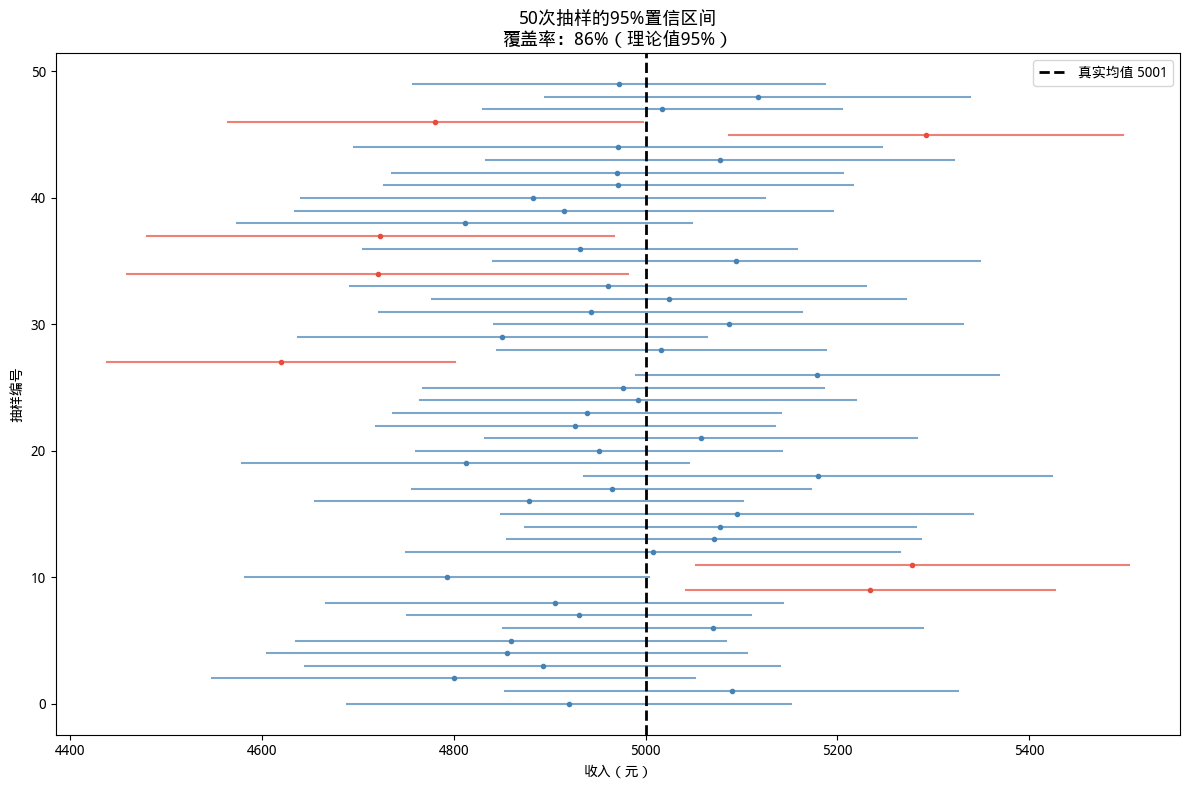

In [3]:
np.random.seed(42)
true_mean = population.mean()
n_trials = 50
coverage_count = 0

fig, ax = plt.subplots(figsize=(12, 8))

for i in range(n_trials):
    sample_i = np.random.choice(population, 50)
    
    ci_i = stats.t.interval(0.95, df=49, loc=sample_i.mean(), scale=stats.sem(sample_i))
    contains = ci_i[0] <= true_mean <= ci_i[1]
    if contains:
        coverage_count += 1
    color = 'steelblue' if contains else '#E74C3C'
    ax.plot([ci_i[0], ci_i[1]], [i, i], color=color, linewidth=1.5, alpha=0.7)
    ax.plot(sample_i.mean(), i, 'o', color=color, markersize=3)

ax.axvline(x=true_mean, color='black', linewidth=2, linestyle='--', label=f'真实均值 {true_mean:.0f}')
ax.set_title(f'50次抽样的95%置信区间\n覆盖率：{coverage_count/n_trials*100:.0f}%（理论值95%）',
              fontsize=13, fontweight='bold')
ax.set_xlabel('收入（元）')
ax.set_ylabel('抽样编号')
ax.legend()
plt.tight_layout()
plt.show()


蓝色线包住了真实均值（正确），红色线没有包住（这次抽样运气不好）。理论上 50 条里应该约有 47~48 条是蓝色。

---

## 四、置信区间的宽度

置信区间宽度 = 2 × z × σ/√n

影响宽度的三个因素：


In [4]:
print("置信区间宽度的影响因素：")
print()

base_ci = 2 * 1.96 * 800 / np.sqrt(100)
print(f"基准（n=100, 95%）：±{base_ci/2:.1f}（宽度={base_ci:.1f}）")

# 增大样本量
ci_n400 = 2 * 1.96 * 800 / np.sqrt(400)
print(f"n=400（4倍）：±{ci_n400/2:.1f}（宽度缩小 {base_ci/ci_n400:.1f}x）")

# 提高置信度
z_99 = stats.norm.ppf(0.995)
ci_99 = 2 * z_99 * 800 / np.sqrt(100)
print(f"99% 置信度：±{ci_99/2:.1f}（宽度扩大，更保守）")

# 总体标准差更小
ci_sigma400 = 2 * 1.96 * 400 / np.sqrt(100)
print(f"σ=400（减半）：±{ci_sigma400/2:.1f}（宽度缩小一半）")


置信区间宽度的影响因素：

基准（n=100, 95%）：±156.8（宽度=313.6）
n=400（4倍）：±78.4（宽度缩小 2.0x）
99% 置信度：±206.1（宽度扩大，更保守）
σ=400（减半）：±78.4（宽度缩小一半）


**结论**：想要更窄的区间（更精准的估计），要么增大样本量，要么降低置信度，要么减小总体变异。

---

## 五、比例的置信区间

不只是均值，比例（如转化率）也可以做置信区间：


In [8]:
from statsmodels.stats.proportion import proportion_confint
# 调查 500 人，200 人表示会购买（转化率 40%）
n_survey = 500
n_buy = 200
p_hat = n_buy / n_survey

# 威尔逊置信区间（比简单公式更稳健）
ci_prop = proportion_confint(n_buy, n_survey, alpha=0.05, method='wilson')
print(f"\n转化率估计：{p_hat:.1%}")
print(f"95% 置信区间：({ci_prop[0]:.1%}, {ci_prop[1]:.1%})")
print(f"即：{p_hat:.1%} ± {(ci_prop[1]-ci_prop[0])/2:.1%}")



转化率估计：40.0%
95% 置信区间：(35.8%, 44.4%)
即：40.0% ± 4.3%


---

## 六、🔧 综合实战：电商客单价分析

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


各城市客单价 95% 置信区间
城市       样本量         均值     95% CI下限     95% CI上限
-------------------------------------------------------
上海        60        924          721        1,127
北京        59        891          699        1,083
广州        60        887          664        1,110
杭州        59        794          625          963
深圳        62        662          555          769



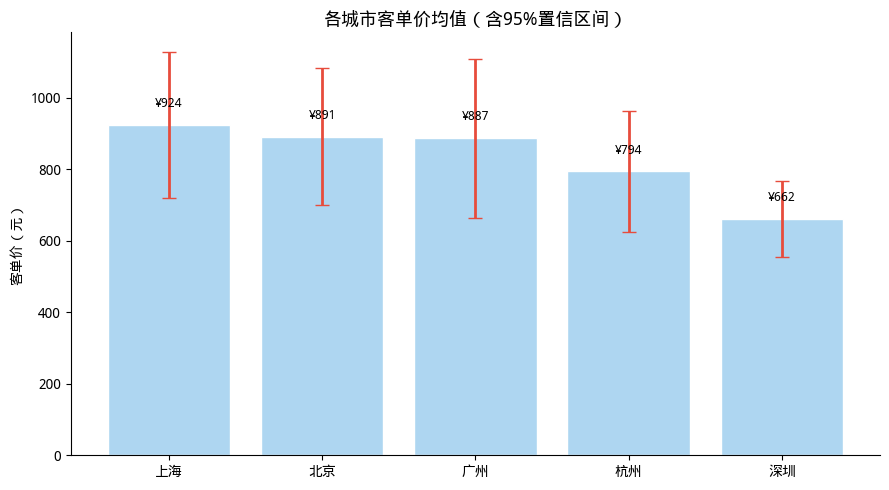

In [6]:
import pandas as pd
import numpy as np
from scipy import stats

np.random.seed(2024)
n = 300

df = pd.DataFrame({
    'city':   np.random.choice(['北京','上海','广州','深圳','杭州'], n),
    'amount': np.random.lognormal(6.5, 0.7, n)
})

print("各城市客单价 95% 置信区间")
print("="*55)
print(f"{'城市':<6} {'样本量':>5} {'均值':>10} {'95% CI下限':>12} {'95% CI上限':>12}")
print("-"*55)

for city in sorted(df['city'].unique()):
    subset = df[df['city'] == city]['amount']
    
    ci = stats.t.interval(0.95, df=len(subset)-1, loc=subset.mean(), scale=stats.sem(subset))
    print(f"{city:<6} {len(subset):>5} {subset.mean():>10,.0f} {ci[0]:>12,.0f} {ci[1]:>12,.0f}")

print()
# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

cities = sorted(df['city'].unique())
means, ci_lowers, ci_uppers = [], [], []

for city in cities:
    subset = df[df['city'] == city]['amount']
    ci = stats.t.interval(0.95, df=len(subset)-1, loc=subset.mean(), scale=stats.sem(subset))
    means.append(subset.mean())
    ci_lowers.append(subset.mean() - ci[0])
    ci_uppers.append(ci[1] - subset.mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cities, means, color='#AED6F1', edgecolor='white')
ax.errorbar(cities, means, yerr=[ci_lowers, ci_uppers],
             fmt='none', color='#E74C3C', capsize=5, linewidth=2)

for i, (city, m) in enumerate(zip(cities, means)):
    ax.text(i, m + 50, f'¥{m:.0f}', ha='center', fontsize=9)

ax.set_title('各城市客单价均值（含95%置信区间）', fontsize=13, fontweight='bold')
ax.set_ylabel('客单价（元）')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---

## 七、📝 小结

| 概念 | 含义 |
|------|------|
| 置信区间 | 用样本估计总体参数的区间范围 |
| 置信度 | 如95%，指重复抽样时区间包含真值的比例 |
| 标准误 SE | s/√n，越小估计越精准 |
| 更窄的CI | 需要更大 n 或更小 σ |

---

## 八、🏋️ 课后练习

1. 随机抽取 80 名用户，客单价均值 ¥450，标准差 ¥120，计算 95% 和 99% 置信区间，对比宽度差异。
2. A/B测试中，A 组 200 人有 30 人转化，B 组 200 人有 38 人转化。分别计算两组转化率的 95% 置信区间，区间有重叠吗？
3. 如果想让置信区间宽度缩小到原来的 1/3，需要把样本量增加到多少？

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
# 练习1: 置信区间计算 - 用户客单价
print("练习1: 置信区间估计 - 用户客单价")

# 参数设置
n_users = 80           # 样本量
sample_mean = 450      # 样本均值（元）
sample_std = 120      # 样本标准差（元）

# 由于样本量 n=80 较大，可以使用 z 分数近似
# 但更精确的做法是使用 t 分布（尤其是样本量不太大时）
# 这里使用 t 分布，因为虽然 n=80 较大，但总体标准差未知

# 计算标准误
standard_error = sample_std / np.sqrt(n_users)

print(f"【已知信息】")
print(f"  样本量 n = {n_users}")
print(f"  样本均值 x̄ = {sample_mean} 元")
print(f"  样本标准差 s = {sample_std} 元")
print(f"  标准误 SE = s/√n = {sample_std}/√{n_users} = {standard_error:.4f}")

# 95% 置信区间
confidence_95 = 0.95
alpha_95 = 1 - confidence_95
t_critical_95 = stats.t.ppf(1 - alpha_95/2, df=n_users-1)
margin_95 = t_critical_95 * standard_error
ci_95_lower = sample_mean - margin_95
ci_95_upper = sample_mean + margin_95

print(f"\n【95% 置信区间】")
print(f"  置信水平: {confidence_95*100}%")
print(f"  自由度: df = n-1 = {n_users-1}")
print(f"  t 临界值: t_{alpha_95/2}({n_users-1}) = {t_critical_95:.4f}")
print(f"  误差边界: t × SE = {t_critical_95:.4f} × {standard_error:.4f} = {margin_95:.4f}")
print(f"  置信区间: {sample_mean} ± {margin_95:.4f}")
print(f"  结果: [{ci_95_lower:.2f}, {ci_95_upper:.2f}] 元")

# 99% 置信区间
confidence_99 = 0.99
alpha_99 = 1 - confidence_99
t_critical_99 = stats.t.ppf(1 - alpha_99/2, df=n_users-1)
margin_99 = t_critical_99 * standard_error
ci_99_lower = sample_mean - margin_99
ci_99_upper = sample_mean + margin_99

print(f"\n【99% 置信区间】")
print(f"  置信水平: {confidence_99*100}%")
print(f"  t 临界值: t_{alpha_99/2}({n_users-1}) = {t_critical_99:.4f}")
print(f"  误差边界: t × SE = {t_critical_99:.4f} × {standard_error:.4f} = {margin_99:.4f}")
print(f"  置信区间: {sample_mean} ± {margin_99:.4f}")
print(f"  结果: [{ci_99_lower:.2f}, {ci_99_upper:.2f}] 元")

# 对比宽度差异
width_95 = ci_95_upper - ci_95_lower
width_99 = ci_99_upper - ci_99_lower
print(f"\n【宽度对比】")
print(f"  95% CI 宽度: {width_95:.4f} 元")
print(f"  99% CI 宽度: {width_99:.4f} 元")
print(f"  宽度比值: {width_99/width_95:.4f}")
print(f"  结论: 99% 置信区间比 95% 置信区间宽 {(width_99/width_95-1)*100:.1f}%")
print(f"        更高的置信水平需要更宽的区间来保证覆盖")

练习1: 置信区间估计 - 用户客单价
【已知信息】
  样本量 n = 80
  样本均值 x̄ = 450 元
  样本标准差 s = 120 元
  标准误 SE = s/√n = 120/√80 = 13.4164

【95% 置信区间】
  置信水平: 95.0%
  自由度: df = n-1 = 79
  t 临界值: t_0.025000000000000022(79) = 1.9905
  误差边界: t × SE = 1.9905 × 13.4164 = 26.7047
  置信区间: 450 ± 26.7047
  结果: [423.30, 476.70] 元

【99% 置信区间】
  置信水平: 99.0%
  t 临界值: t_0.0050000000000000044(79) = 2.6395
  误差边界: t × SE = 2.6395 × 13.4164 = 35.4127
  置信区间: 450 ± 35.4127
  结果: [414.59, 485.41] 元

【宽度对比】
  95% CI 宽度: 53.4094 元
  99% CI 宽度: 70.8253 元
  宽度比值: 1.3261
  结论: 99% 置信区间比 95% 置信区间宽 32.6%
        更高的置信水平需要更宽的区间来保证覆盖


In [11]:
# 练习2: A/B测试转化率置信区间
print("练习2: A/B测试转化率置信区间")

# 参数设置
n_A = 200       # A组样本量
conversions_A = 30  # A组转化人数
n_B = 200       # B组样本量
conversions_B = 38  # B组转化人数

# 计算转化率
p_A = conversions_A / n_A
p_B = conversions_B / n_B

print(f"【实验数据】")
print(f"  A组: n = {n_A}, 转化人数 = {conversions_A}, 转化率 = {p_A*100:.2f}%")
print(f"  B组: n = {n_B}, 转化人数 = {conversions_B}, 转化率 = {p_B*100:.2f}%")

# 使用正态近似计算转化率的置信区间
# 标准误 = sqrt(p(1-p)/n)
se_A = np.sqrt(p_A * (1 - p_A) / n_A)
se_B = np.sqrt(p_B * (1 - p_B) / n_B)

# 95%置信区间（使用正态近似）
z_critical = stats.norm.ppf(0.975)  # 1.96

ci_A_lower = p_A - z_critical * se_A
ci_A_upper = p_A + z_critical * se_A

ci_B_lower = p_B - z_critical * se_B
ci_B_upper = p_B + z_critical * se_B

print(f"\n【95% 置信区间计算】")
print(f"  A组转化率标准误: SE_A = √[{p_A:.4f}×(1-{p_A:.4f})/{n_A}] = {se_A:.4f}")
print(f"  B组转化率标准误: SE_B = √[{p_B:.4f}×(1-{p_B:.4f})/{n_B}] = {se_B:.4f}")
print(f"  Z临界值 (95%): {z_critical:.4f}")

print(f"\n【结果】")
print(f"  A组 95% CI: [{ci_A_lower*100:.2f}%, {ci_A_upper*100:.2f}%]")
print(f"           即 [{ci_A_lower:.4f}, {ci_A_upper:.4f}]")
print(f"  B组 95% CI: [{ci_B_lower*100:.2f}%, {ci_B_upper*100:.2f}%]")
print(f"           即 [{ci_B_lower:.4f}, {ci_B_upper:.4f}]")

# 判断区间是否有重叠
print(f"\n【区间重叠分析】")
overlap_lower = max(ci_A_lower, ci_B_lower)
overlap_upper = min(ci_A_upper, ci_B_upper)
overlap = max(0, overlap_upper - overlap_lower)

if overlap > 0:
    print(f"  两个置信区间有重叠区域")
    print(f"  重叠区间: [{overlap_lower*100:.2f}%, {overlap_upper*100:.2f}%]")
    print(f"  重叠程度: {overlap*100:.2f}%")
    print(f"\n  ⚠️ 结论: 由于区间有重叠，我们不能确定B组转化率确实优于A组")
    print(f"          需要更多数据或进一步分析来得出确定结论")
else:
    print(f"  两个置信区间没有重叠")
    print(f"  可以认为B组显著优于A组")

练习2: A/B测试转化率置信区间
【实验数据】
  A组: n = 200, 转化人数 = 30, 转化率 = 15.00%
  B组: n = 200, 转化人数 = 38, 转化率 = 19.00%

【95% 置信区间计算】
  A组转化率标准误: SE_A = √[0.1500×(1-0.1500)/200] = 0.0252
  B组转化率标准误: SE_B = √[0.1900×(1-0.1900)/200] = 0.0277
  Z临界值 (95%): 1.9600

【结果】
  A组 95% CI: [10.05%, 19.95%]
           即 [0.1005, 0.1995]
  B组 95% CI: [13.56%, 24.44%]
           即 [0.1356, 0.2444]

【区间重叠分析】
  两个置信区间有重叠区域
  重叠区间: [13.56%, 19.95%]
  重叠程度: 6.39%

  ⚠️ 结论: 由于区间有重叠，我们不能确定B组转化率确实优于A组
          需要更多数据或进一步分析来得出确定结论


In [12]:
# 练习3: 缩小置信区间所需的样本量
print("练习3: 缩小置信区间到1/3所需的样本量")

print("【问题分析】")
print("置信区间宽度公式: W = 2 × Z × SE = 2 × Z × (σ/√n)")
print("宽度与样本量的关系: W ∝ 1/√n")
print()
print("若要将宽度缩小到原来的 1/3:")
print("  新宽度 = 原宽度 / 3")
print("  新宽度 ∝ 1/√(n_new)")
print("  原宽度 ∝ 1/√(n_original)")
print("  1/√(n_new) = (1/3) × 1/√(n_original)")
print("  √(n_new) = 3 × √(n_original)")
print("  n_new = 9 × n_original")

# 使用练习1的数据
n_original = n_users
n_new_required = 9 * n_original

print(f"\n【计算结果】")
print(f"  原样本量 n = {n_original}")
print(f"  新样本量 n = {n_original} × 9 = {n_new_required}")

# 验证宽度变化
# 使用 t 分布近似计算
original_width = 2 * t_critical_95 * (sample_std / np.sqrt(n_original))
new_width = 2 * t_critical_95 * (sample_std / np.sqrt(n_new_required))

print(f"\n【验证】")
print(f"  原置信区间宽度 ≈ {original_width:.4f} 元")
print(f"  新置信区间宽度 ≈ {new_width:.4f} 元")
print(f"  宽度比值 = {new_width/original_width:.4f} ≈ 1/3")

print(f"\n【结论】需要将样本量增加到原来的 9 倍")

练习3: 缩小置信区间到1/3所需的样本量
【问题分析】
置信区间宽度公式: W = 2 × Z × SE = 2 × Z × (σ/√n)
宽度与样本量的关系: W ∝ 1/√n

若要将宽度缩小到原来的 1/3:
  新宽度 = 原宽度 / 3
  新宽度 ∝ 1/√(n_new)
  原宽度 ∝ 1/√(n_original)
  1/√(n_new) = (1/3) × 1/√(n_original)
  √(n_new) = 3 × √(n_original)
  n_new = 9 × n_original

【计算结果】
  原样本量 n = 80
  新样本量 n = 80 × 9 = 720

【验证】
  原置信区间宽度 ≈ 53.4094 元
  新置信区间宽度 ≈ 17.8031 元
  宽度比值 = 0.3333 ≈ 1/3

【结论】需要将样本量增加到原来的 9 倍


本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 35 篇：假设检验 — p 值到底是什么意思**
>
> 置信区间是「估计」，下篇进入「检验」——假设检验和 p 值，p < 0.05 到底意味着什么？

---

*跟着小荷，数据分析路上不迷路～*